![](../img/330-banner.png)

# (Optional)<br>Lecture 25: Stochastic Gradient Descent (SGD)

UBC 2025-26

<br>

This lecture is optional and will **not be included in the exam**.

<br>


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import Ridge, LogisticRegression, SGDClassifier, SGDRegressor
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import CountVectorizer

plt.rcParams['font.size'] = 16

## For large datasets: `SGDClassifier` and `SGDRegressor`

***Note*** 
Although we speak of very large datasets here, we do *not* mean what is commonly referred to as *Big Data*. A common (though informal) threshold for Big Data is datasets on the order of *a terabyte* or more. Handling such datasets typically requires additional infrastructure and tools, which we do not cover here.

- Something we haven't discussed in this course is large data sets.
- There could be a couple of problems arising from large data sets:
  1. The code is too slow.
  2. The dataset doesn't fit in memory - we can't even load it with `pd.read_csv`. 

Simplest strategy: subset your data for experimentation / hyperparameter tuning, then train your final model on the whole dataset (once).

- "SGD" (stochastic gradient descent) can help with both of these problems.
- But we'll focus on using it to solve problem (1).
- There is a fancy way to implement `fit` that can be a lot faster for large datasets.
  - You can **think of it as quickly finding "approximately" the best coefficients** when calling `fit`.
  - That is not quite true but it may be a useful way of thinking.
  - Much more on this in CPSC 340 and much, much more on this in CPSC 440/540.

- SGD can be used in many contexts.
- In sklearn, it's built in as follows:

In [2]:
from sklearn.linear_model import SGDClassifier, SGDRegressor

- `SGDRegressor` is basically equivalent to `Ridge`.
- `SGDRegressor(loss='huber')` is basically equivalent to `HuberRegressor`.
- `SGDClassifier(loss='log_loss')` is basically equivalent to `LogisticRegression`, except the parameter is called `alpha` instead of `C` (like `Ridge`).
- With other settings they are equivalent to other models, but this is good enough.

- For **regular sized** datasets, use the **original functions**, as these ones can be a bit more finicky.
  - In general, SGD is best suited for large‑scale, streaming, or resource‑constrained problems with simple models, but it is rarely the best default choice for small or medium datasets.

Let's load this [Sentiment dataset](https://www.kaggle.com/ferno2/training1600000processednoemoticoncsv), which contains tweets labeled with sentiment associated with a brand, product, or topic. It is **a large dataset**.

In [3]:
tweets_df = pd.read_csv('../data/training.1600000.processed.noemoticon.csv', 
                        encoding = "ISO-8859-1",
                        names=["label", "id", "date", "no_query", "name", "text"])
tweets_df['label'] = tweets_df['label'].map({0: 'neg', 4: 'pos'})
tweets_df = tweets_df[tweets_df['label'].str.startswith(('pos','neg'))]

In [4]:
tweets_df_train, tweets_df_test = train_test_split(tweets_df)

In [5]:
tweets_df_train.head()

,label,id,date,no_query,name,text
513400,neg,2190376542,Tue Jun 16 02:33:10 PDT 2009,NO_QUERY,katelimlengco,Doing homework.( Lots of it!) Also studying f...
819961,pos,1553583906,Sat Apr 18 14:39:43 PDT 2009,NO_QUERY,imaginarycanary,My reading is tonight in San Francisco's Missi...
698309,neg,2254083205,Sat Jun 20 09:12:04 PDT 2009,NO_QUERY,imeveeweavers,"well todaay has been an alright daay, just mis..."
201154,neg,1971832180,Sat May 30 07:59:53 PDT 2009,NO_QUERY,MissWinny,About to get ready to go to North Carolina for...
12380,neg,1551778040,Sat Apr 18 09:57:02 PDT 2009,NO_QUERY,jackieCSWS,@Mayday_Parade no you wont i dont have a ride


In [6]:
tweets_df_train.shape

(1200000, 6)

Holy cow!

In [7]:
vec = CountVectorizer(stop_words='english')

X_train = vec.fit_transform(tweets_df_train['text']) 
y_train = tweets_df_train['label']

X_test = vec.transform(tweets_df_test['text']) 
y_test = tweets_df_test['label']

In [8]:
X_train.shape

(1200000, 564097)

In [9]:
type(X_train)

scipy.sparse._csr.csr_matrix

Here is the **fraction of elements that are nonzero**, showing that having a sparse matrix really helps!!

In [10]:
X_train.nnz / np.prod(X_train.shape)

np.float64(1.2338177949300682e-05)

Now let's train a classifier. I'll use `%time` instead of `%timeit` because I want to keep the output, and it gets lost with `%timeit`.

In [11]:
dc = DummyClassifier()
dc.fit(X_train, y_train)
dc.score(X_train, y_train)

0.5000433333333333

In [12]:
lr = LogisticRegression()

In [13]:
%time lr.fit(X_train, y_train);

CPU times: user 3min 55s, sys: 3.5 s, total: 3min 58s
Wall time: 21.5 s


/home/mehrdad/miniconda3/envs/cpsc330/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In `LogisticRegression`, the hyperparameter `max_iter` is set to 100 by default. We could increase it to get rid of this warning, but it would then take even longer to run `fit()`.

In [14]:
lr.score(X_train, y_train)

0.81296

In [15]:
lr.score(X_test, y_test)

0.778

In [16]:
lr.n_iter_

array([100], dtype=int32)

Now, let's try to use `SGDClassifier` on the same data:

In [17]:
lr_sgd = SGDClassifier(loss="log_loss")

In [18]:
%time lr_sgd.fit(X_train, y_train);

CPU times: user 7.45 s, sys: 132 ms, total: 7.58 s
Wall time: 5.15 s


In [19]:
lr_sgd.n_iter_

7

In [20]:
lr_sgd.score(X_train, y_train)

0.7698733333333333

In [21]:
lr_sgd.score(X_test, y_test)

0.7665925

- `SGDClassifier` was **many folds faster** than `LogisticRegression`, but the accuracy is slightly lower.
- In fact, we can control the speed vs. _train_ accuracy tradeoff in both cases using the hyperparameters.
  - The main ones are `max_iter` (higher is slower) and/or `tol` (lower is slower)
  - (This is the same for both `LogisticRegression` and `SGDClassifier`)
  - This is analogous to `n_iter` in `RandomizedSearchCV` !
- In general, `LogisticRegression` will get slightly higher _train_ accuracy (may or may not correspond to better validation/test)
- But in some cases your **dataset is so big** that `LogisticRegression` is **not feasible**, and then `SGDClassifier` can save the day.

In [22]:
# from https://scikit-learn.org/stable/auto_examples/linear_model/plot_sgd_early_stopping.html#sphx-glr-auto-examples-linear-model-plot-sgd-early-stopping-py

from sklearn.utils._testing import ignore_warnings
from sklearn.exceptions import ConvergenceWarning

@ignore_warnings(category=ConvergenceWarning)
def fit_grid_search_lr(iters):
    grid_search_lr = GridSearchCV(
        LogisticRegression(), 
        {"max_iter" : iters}, return_train_score=True, verbose=2, cv=2, n_jobs=-1)
    # n_jobs=-1 might mess up the timing a bit but otherwise it takes too long
    grid_search_lr.fit(X_train, y_train)
    return grid_search_lr

grid_search_lr = fit_grid_search_lr([3, 10, 30, 100])

Fitting 2 folds for each of 4 candidates, totalling 8 fits


In [23]:
results_lr = pd.DataFrame(grid_search_lr.cv_results_)
results_lr

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_iter,params,split0_test_score,split1_test_score,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,mean_train_score,std_train_score
0,1.723207,0.040841,0.983591,0.035888,3,{'max_iter': 3},0.678290,0.675888,0.677089,0.001201,4,0.677867,0.677095,0.677481,0.000386
1,2.814309,0.010787,0.991259,0.024873,10,{'max_iter': 10},0.752397,0.752693,0.752545,0.000148,3,0.755363,0.755612,0.755488,0.000124
2,5.981470,0.044035,0.859519,0.044804,30,{'max_iter': 30},0.770280,0.770745,0.770512,0.000233,2,0.781923,0.784610,0.783267,0.001343
3,16.236624,0.108057,0.776214,0.014565,100,{'max_iter': 100},0.772540,0.772618,0.772579,0.000039,1,0.825575,0.827797,0.826686,0.001111


In [24]:
grid_search_sgd = GridSearchCV(
    SGDClassifier(loss="log_loss", max_iter=100_000),
    {"tol" : [1e-3, 1e-4, 1e-5]},
    return_train_score=True, verbose=2, cv=2, n_jobs=-1)

grid_search_sgd.fit(X_train, y_train);

Fitting 2 folds for each of 3 candidates, totalling 6 fits


In [25]:
results_sgd = pd.DataFrame(grid_search_sgd.cv_results_)
results_sgd

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_tol,params,split0_test_score,split1_test_score,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,mean_train_score,std_train_score
0,3.716071,0.009631,0.677745,0.006589,0.00100,{'tol': 0.001},0.765373,0.765570,0.765472,0.000098,1,0.771837,0.772883,0.772360,0.000523
1,5.897431,0.177197,0.551014,0.020494,0.00010,{'tol': 0.0001},0.765478,0.765437,0.765458,0.000021,2,0.772238,0.772812,0.772525,0.000287
2,15.366314,0.440220,0.540789,0.009722,0.00001,{'tol': 1e-05},0.765420,0.765338,0.765379,0.000041,3,0.772157,0.772815,0.772486,0.000329


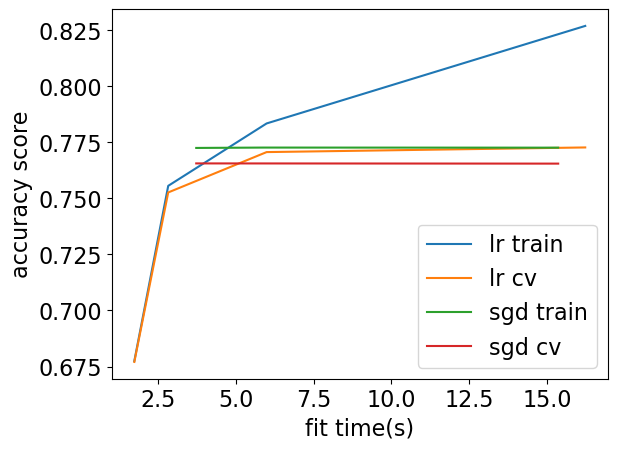

In [26]:
plt.plot(results_lr["mean_fit_time"], results_lr["mean_train_score"], label="lr train")
plt.plot(results_lr["mean_fit_time"], results_lr["mean_test_score"], label="lr cv")
plt.plot(results_sgd["mean_fit_time"], results_sgd["mean_train_score"], label="sgd train")
plt.plot(results_sgd["mean_fit_time"], results_sgd["mean_test_score"], label="sgd cv")
plt.xlabel("fit time(s)");
plt.ylabel("accuracy score");
plt.legend();

<br><br>

TL;DR if you don't want to wait that long, `SGDClassifier` will probably do better on a large dataset.